# Part A

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
orders = pd.read_excel("Customer_Orders_Dataset.xlsx")
customers = pd.read_excel("Customer name data.xlsx")

# Merge
df = pd.merge(orders, customers, on='CustomerID')
df.rename(columns={'Country_x': 'Country'}, inplace=True)

print("Shape:", df.shape)
print(df.head(3))

Shape: (39995, 19)
   OrderID  CustomerID           OrderDate   Segment        Country  \
0    16704           1 2023-10-07 07:00:00  Consumer  United States   
1    25572           1 2024-10-10 19:00:00  Consumer  United States   
2    33328           1 2022-08-29 23:00:00  Consumer  United States   

         City       State  Postal Code Region       Product ID  \
0  Long Beach  California        90805   West  TEC-PH-10002468   
1    Pasadena  California        91104   West  FUR-FU-10004864   
2     Oakland  California        94601   West  OFF-BI-10000962   

          Category Sub-Category  \
0       Technology       Phones   
1        Furniture  Furnishings   
2  Office Supplies      Binders   

                                        Product Name    Sales  Quantity  \
0  Plantronics CS 50-USB -Â headsetÂ - Convertibl...  217.584         2   
1  Howard Miller 14-1/2" Diameter Chrome Round Wa...  383.640         6   
2  Acco Flexible ACCOHIDE Square Ring Data Binder...  117.144    



### 📌 **Basic Data Exploration**

1. How many unique customers placed orders?
2. What are the top 5 countries by number of customers?
3. How many total orders are there?
4. What is the range of order dates in the dataset?

---

### 📊 **Sales & Profit Analysis**

5. What is the **total sales**, **total profit**, and **average discount**?
6. Which **category** has the highest **total sales**?
7. Which **sub-category** has the lowest **average profit**?
8. What is the **total quantity sold** per category?
9. Which **product** generated the most **profit**?

---

### 🌍 **Geographical Analysis**

10. Which **state** had the highest sales in the "Technology" category?
11. Compare **sales by region** – which region earns the most?
12. In which **city** were the most orders placed?

---

### 📦 **Customer-Centric Analysis**

13. Which customer made the **highest number of purchases**?
14. What is the **total revenue generated by CustomerID 1**?
15. Who are the **top 10 customers by profit earned**?

---

### 📅 **Time Series Analysis**

16. What is the **monthly trend** of sales and profit?
17. Which **year** had the highest total orders?
18. Did discounts improve or reduce profit over time?

---

### 🛍️ **Product-Level Analysis**

19. What are the top 5 most sold products by quantity?
20. Are there products that were sold at a **0% discount** but still made high profits?

---

### 🧠 **Advanced Analytical Insights**

21. Is there any correlation between discount and profit?
22. What is the **average profit margin** per product category?
23. Can you find **repeat purchases** by the same customer?
24. Which customers placed **high-value orders (above ₹500)** multiple times?
25. Create a **RFM analysis** (Recency, Frequency, Monetary) to identify loyal customers.

---


In [ ]:
# Q1 - Unique Customers
print("Q1 - Unique Customers:", df['CustomerID'].nunique())

# Q2 - Top 5 Countries
print("\nQ2 - Top 5 Countries:")
print(df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head())

# Q3 - Total Orders
print("\nQ3 - Total Orders:", df['OrderID'].nunique())

# Q4 - Date Range
print("\nQ4 - Date Range:", df['OrderDate'].min(), "to", df['OrderDate'].max())

In [ ]:
# Q5
print("Q5 - Total Sales:", round(df['Sales'].sum(), 2))
print("     Total Profit:", round(df['Profit'].sum(), 2))
print("     Avg Discount:", round(df['Discount'].mean(), 4))

# Q6
print("\nQ6 - Category with Highest Sales:")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

# Q7
print("\nQ7 - Sub-Category with Lowest Avg Profit:")
print(df.groupby('Sub-Category')['Profit'].mean().sort_values().head(1))

# Q8
print("\nQ8 - Total Quantity per Category:")
print(df.groupby('Category')['Quantity'].sum())

# Q9
print("\nQ9 - Product with Most Profit:")
print(df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(1))

In [ ]:
# Q10
print("Q10 - State with Highest Sales in Technology:")
tech = df[df['Category'] == 'Technology']
print(tech.groupby('State')['Sales'].sum().sort_values(ascending=False).head(1))

# Q11
print("\nQ11 - Sales by Region:")
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False))

# Q12
print("\nQ12 - City with Most Orders:")
print(df.groupby('City')['OrderID'].nunique().sort_values(ascending=False).head(1))

In [ ]:
# Q13
print("Q13 - Customer with Most Purchases:")
print(df.groupby('FullName')['OrderID'].nunique().sort_values(ascending=False).head(1))

# Q14
print("\nQ14 - Total Revenue by CustomerID 1:")
print(round(df[df['CustomerID'] == 1]['Sales'].sum(), 2))

# Q15
print("\nQ15 - Top 10 Customers by Profit:")
print(df.groupby('FullName')['Profit'].sum().sort_values(ascending=False).head(10))

In [ ]:
# Q16
df['Month'] = df['OrderDate'].dt.to_period('M')
monthly = df.groupby('Month')[['Sales', 'Profit']].sum()
print("Q16 - Monthly Sales & Profit Trend:")
print(monthly.tail(12))

# Q17
print("\nQ17 - Year with Highest Orders:")
df['Year'] = df['OrderDate'].dt.year
print(df.groupby('Year')['OrderID'].nunique().sort_values(ascending=False).head(1))

# Q18
print("\nQ18 - Discount vs Profit Correlation:")
print(round(df[['Discount', 'Profit']].corr(), 3))

In [ ]:
# Q19
print("Q19 - Top 5 Products by Quantity:")
print(df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(5))

# Q20
zero_disc = df[df['Discount'] == 0]
print("\nQ20 - 0% Discount but High Profit Products:")
print(zero_disc.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(5))

In [2]:
# Q21
print("Q21 - Correlation: Discount vs Profit:")
print(round(df['Discount'].corr(df['Profit']), 3))

# Q22
df['Profit Margin'] = df['Profit'] / df['Sales']
print("\nQ22 - Avg Profit Margin per Category:")
print(df.groupby('Category')['Profit Margin'].mean().round(3))

# Q23
repeat = df.groupby('CustomerID')['OrderID'].nunique()
print("\nQ23 - Repeat Customers (more than 1 order):", (repeat > 1).sum())

# Q24
high_value = df[df['Sales'] > 500]
print("\nQ24 - Customers with High-Value Orders (>500) multiple times:")
print(high_value.groupby('FullName')['OrderID'].nunique().sort_values(ascending=False).head(10))

# Q25 - RFM Analysis
import datetime
snapshot_date = df['OrderDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency=('OrderDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('OrderID', 'nunique'),
    Monetary=('Sales', 'sum')
).round(2)
print("\nQ25 - RFM Analysis (Top 10):")
print(rfm.sort_values('Monetary', ascending=False).head(10))

Q21 - Correlation: Discount vs Profit:
-0.22

Q22 - Avg Profit Margin per Category:
Category
Furniture          inf
Office Supplies    inf
Technology         inf
Name: Profit Margin, dtype: float64

Q23 - Repeat Customers (more than 1 order): 9083

Q24 - Customers with High-Value Orders (>500) multiple times:
FullName
Emily Brown       72
David Martinez    63
John Smith        62
Linda Brown       62
John Davis        59
Sarah Martinez    58
Robert Johnson    58
Jane Johnson      58
David Jones       58
Laura Jones       57
Name: OrderID, dtype: int64

Q25 - RFM Analysis (Top 10):
            Recency  Frequency  Monetary
CustomerID                              
6369            882          3  23837.24
93              619          6  23495.43
4955             49          4  23405.95
140             932          3  22702.06
9795             31          4  20295.28
4925           1200          2  18030.29
4962             85          4  18009.60
2257            226         10  18002.68
62

# Part B

In [3]:
# Q22 - Fixed Profit Margin (Sales > 0 wale rows only)
df_valid = df[df['Sales'] > 0].copy()
df_valid['Profit Margin'] = df_valid['Profit'] / df_valid['Sales']
print("Q22 - Avg Profit Margin per Category:")
print(df_valid.groupby('Category')['Profit Margin'].mean().round(3))

Q22 - Avg Profit Margin per Category:
Category
Furniture          0.039
Office Supplies    0.138
Technology         0.156
Name: Profit Margin, dtype: float64



## 🟢 1. **Data Collection Questions**

(Understand the source, structure, and relevance of your dataset.)

* What is the origin of the dataset?
* What are the key tables/files in the dataset?
* What is the total number of rows and columns?
* What are the primary keys and foreign keys?
* What is the time range of the data?
* Is the data structured, semi-structured, or unstructured?
* Are all required columns present?
* How frequently is the data updated?
* Is the data complete and representative of the problem domain?
* What are the data formats (CSV, Excel, SQL, JSON)?

---

## 🧹 2. **Data Cleaning Questions**

(Ensure the data is accurate, consistent, and usable.)

* Are there any missing values? Which columns?
* What strategy should we use to handle missing data?
* Are there duplicate rows in the dataset?
* Are all data types appropriate (dates as datetime, numbers as int/float)?
* Are categorical values consistent (e.g., "Male", "male", "M")?
* Are there outliers in numerical columns?
* Are there irrelevant columns to drop?
* Are there columns with constant or near-constant values?
* Are there spelling errors in names or categories?
* Are there negative or impossible values (e.g., negative prices)?
* Are all dates in a valid format?
* Are any values incorrectly encoded or misaligned?

---

## 📊 3. **Exploratory Data Analysis (EDA) & Modeling Questions**

(Understand patterns, relationships, and build simple models.)

### 🔹 General Summary:

* What are the top-level summary statistics (mean, median, std)?
* What are the most and least frequent values in each column?
* What is the correlation between numerical columns?
* What is the distribution of each numerical feature?

### 🔹 Customer or User Analysis:

* How many unique customers/users are there?
* Which customer placed the most orders?
* What is the average order value per customer?
* Who are the top 10 customers by revenue?
* What’s the repeat purchase rate?

### 🔹 Sales or Product Analysis:

* What is the total revenue, profit, and quantity sold?
* Which products sell the most by quantity? By revenue?
* What are the top-performing categories or sub-categories?
* What is the average discount offered per product?
* Are high-discount items resulting in profit or loss?

### 🔹 Time-Based Analysis:

* How are sales trending month over month?
* What is the best-performing day of the week?
* How does customer activity change over time?
* What is the year-over-year growth in revenue?

### 🔹 Geo or Region-Based Analysis:

* Which states/countries/regions generate the most revenue?
* Where is profit the highest or lowest?
* Are there regions with consistent losses?

### 🔹 Inventory and Shipping:

* What is the average shipping time?
* Which products take the longest to ship?
* Is there a correlation between delivery time and customer rating?

### 🔹 Predictive Modeling (Advanced):

* Can we predict profit based on sales, quantity, discount?
* Can we cluster customers based on spending behavior?
* Can we classify high-value customers using logistic regression?
* Can we forecast future sales using time series?

---

## 📈 4. **Data Visualization Questions**

(Create insights through visual storytelling.)

* What is the monthly sales trend over time? (line plot)
* What is the distribution of sales/profit/discount? (histogram)
* What is the sales share by region? (pie chart)
* How do discounts vary by sub-category? (box plot)
* Which product categories are most profitable? (bar plot)
* What are the top 10 products by revenue? (horizontal bar)
* What’s the correlation between quantity and sales? (scatter plot)
* Which customers contribute the most revenue? (Pareto chart)
* How does shipping delay impact customer satisfaction? (heatmap)
* Can we visualize clusters of customers by behavior? (scatter with KMeans clusters)

---

In [4]:
# Part B - 1. Data Collection Questions

print("=== DATA COLLECTION QUESTIONS ===\n")

print("1. Origin: Customer Orders dataset - retail/e-commerce sales data")
print("2. Key Files: Customer_Orders_Dataset.xlsx, Customer name data.xlsx")
print("3. Total Rows & Columns:", df.shape)
print("4. Primary Key: OrderID | Foreign Key: CustomerID")
print("5. Time Range:", df['OrderDate'].min().date(), "to", df['OrderDate'].max().date())
print("6. Data Type: Structured (tabular)")
print("7. All required columns present:", df.columns.tolist())
print("8. Data update frequency: Static dataset (historical)")
print("9. Missing Values:\n", df.isnull().sum())
print("10. Data Format: Excel (.xlsx)")

=== DATA COLLECTION QUESTIONS ===

1. Origin: Customer Orders dataset - retail/e-commerce sales data
2. Key Files: Customer_Orders_Dataset.xlsx, Customer name data.xlsx
3. Total Rows & Columns: (39995, 20)
4. Primary Key: OrderID | Foreign Key: CustomerID
5. Time Range: 2020-01-01 to 2024-12-31
6. Data Type: Structured (tabular)
7. All required columns present: ['OrderID', 'CustomerID', 'OrderDate', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Country_y', 'FullName', 'Profit Margin']
8. Data update frequency: Static dataset (historical)
9. Missing Values:
 OrderID          0
CustomerID       0
OrderDate        0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit      

In [5]:
print("=== DATA CLEANING QUESTIONS ===\n")

# Missing values
print("1. Missing Values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("   → No missing values found!\n")

# Duplicates
print("2. Duplicate Rows:", df.duplicated().sum())

# Data types
print("\3. Data Types:\n", df.dtypes)

# Outliers in Sales
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Sales'] < Q1 - 1.5*IQR) | (df['Sales'] > Q3 + 1.5*IQR)]
print("\n4. Outliers in Sales:", len(outliers))

# Negative values
print("5. Negative Sales:", (df['Sales'] < 0).sum())
print("   Negative Profit:", (df['Profit'] < 0).sum())

# Unique categories check
print("\n6. Unique Categories:", df['Category'].unique())
print("   Unique Segments:", df['Segment'].unique())
print("   Unique Regions:", df['Region'].unique())

=== DATA CLEANING QUESTIONS ===

1. Missing Values:
 Series([], dtype: int64)
   → No missing values found!

2. Duplicate Rows: 0
. Data Types:
 OrderID                   int64
CustomerID                int64
OrderDate        datetime64[ns]
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Country_y                object
FullName                 object
Profit Margin           float64
dtype: object

4. Outliers in Sales: 4670
5. Negative Sales: 0
   Negative Profit: 7487

6. Unique Categories: ['Technology' 'Furniture' 'Office Supplies']
   Unique Segments: ['Consumer' 'Corporate' 'Home Office']

In [6]:
print("=== EDA & SUMMARY STATISTICS ===\n")
print(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2))

# Correlation
print("\nCorrelation Matrix:")
print(df[['Sales', 'Quantity', 'Discount', 'Profit']].corr().round(3))

=== EDA & SUMMARY STATISTICS ===

          Sales  Quantity  Discount    Profit
count  39995.00  39995.00  39995.00  39995.00
mean     229.76      3.79      0.16     28.65
std      623.12      2.22      0.21    234.21
min        0.00      1.00      0.00  -6599.98
25%       17.24      2.00      0.00      1.73
50%       54.38      3.00      0.20      8.67
75%      209.94      5.00      0.20     29.36
max    22638.48     14.00      0.80   8399.98

Correlation Matrix:
          Sales  Quantity  Discount  Profit
Sales     1.000     0.201    -0.028   0.479
Quantity  0.201     1.000     0.009   0.066
Discount -0.028     0.009     1.000  -0.220
Profit    0.479     0.066    -0.220   1.000


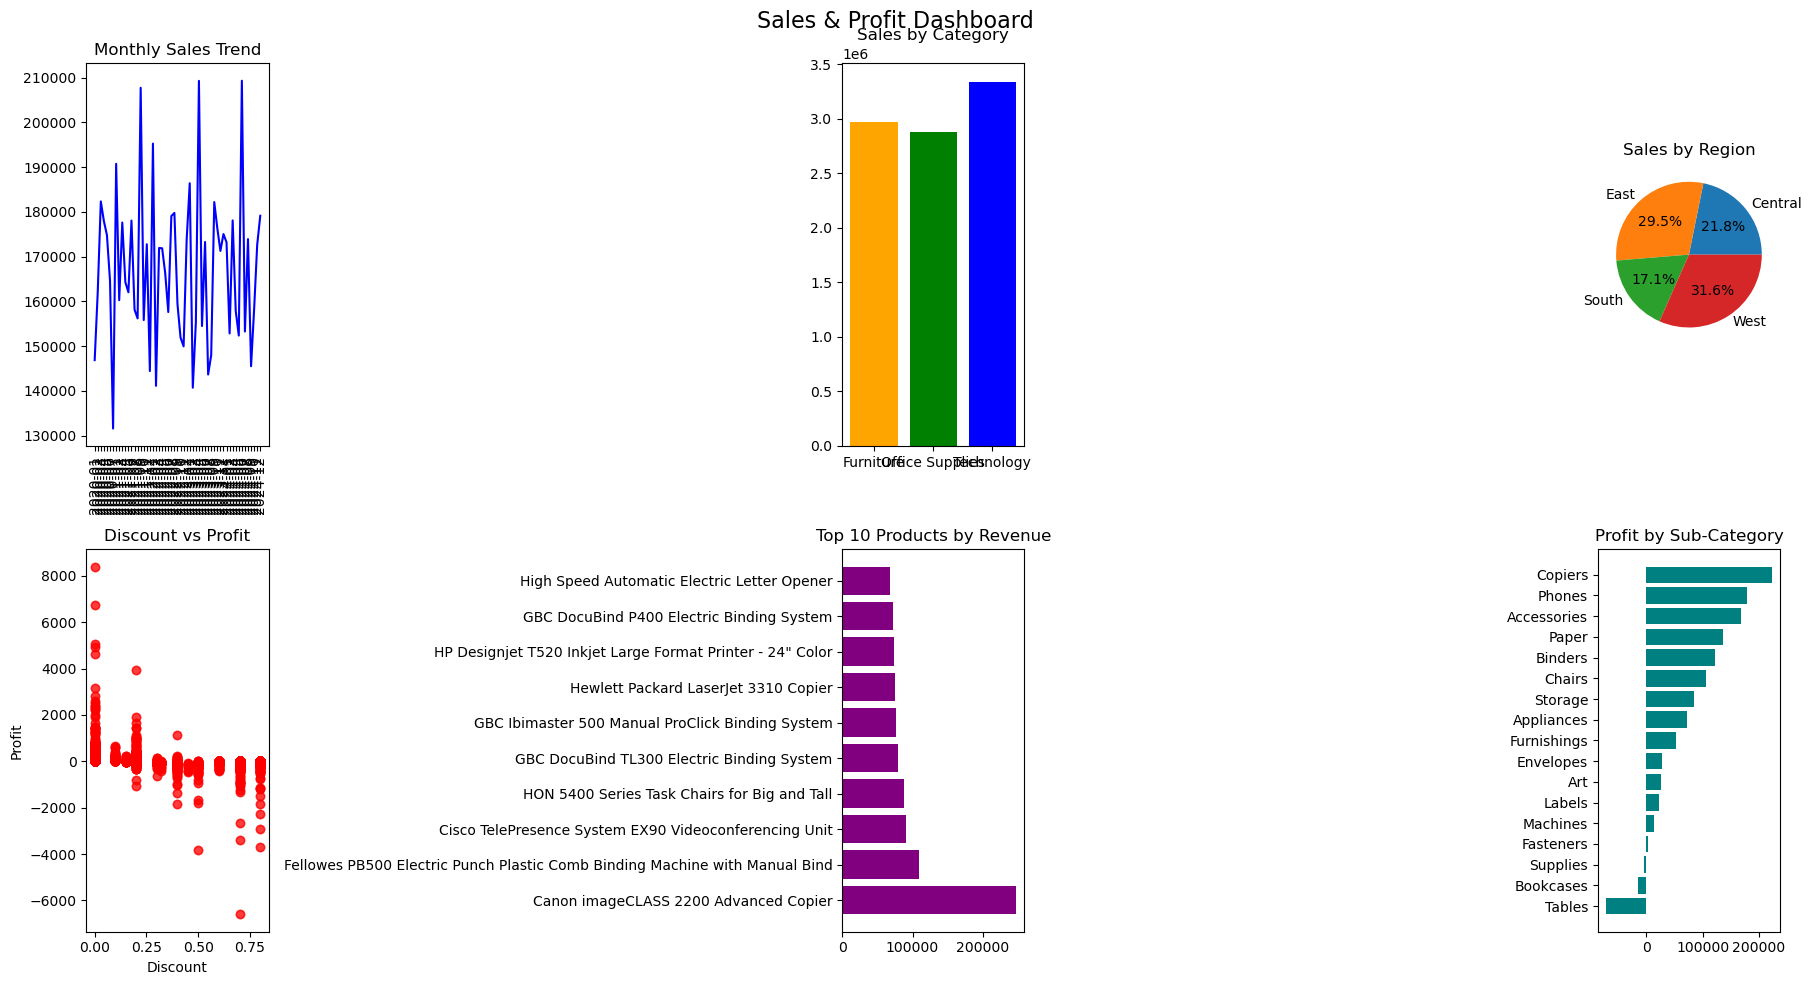

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sales & Profit Dashboard', fontsize=16)

# 1. Monthly Sales Trend
monthly = df.groupby(df['OrderDate'].dt.to_period('M'))['Sales'].sum()
axes[0,0].plot(monthly.index.astype(str), monthly.values, color='blue')
axes[0,0].set_title('Monthly Sales Trend')
axes[0,0].tick_params(axis='x', rotation=90)

# 2. Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum()
axes[0,1].bar(cat_sales.index, cat_sales.values, color=['orange','green','blue'])
axes[0,1].set_title('Sales by Category')

# 3. Sales by Region (Pie)
region_sales = df.groupby('Region')['Sales'].sum()
axes[0,2].pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%')
axes[0,2].set_title('Sales by Region')

# 4. Discount vs Profit (Scatter)
axes[1,0].scatter(df['Discount'], df['Profit'], alpha=0.3, color='red')
axes[1,0].set_title('Discount vs Profit')
axes[1,0].set_xlabel('Discount')
axes[1,0].set_ylabel('Profit')

# 5. Top 10 Products by Revenue
top10 = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
axes[1,1].barh(top10.index, top10.values, color='purple')
axes[1,1].set_title('Top 10 Products by Revenue')

# 6. Profit by Sub-Category
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
axes[1,2].barh(sub_profit.index, sub_profit.values, color='teal')
axes[1,2].set_title('Profit by Sub-Category')

plt.tight_layout()
plt.show()

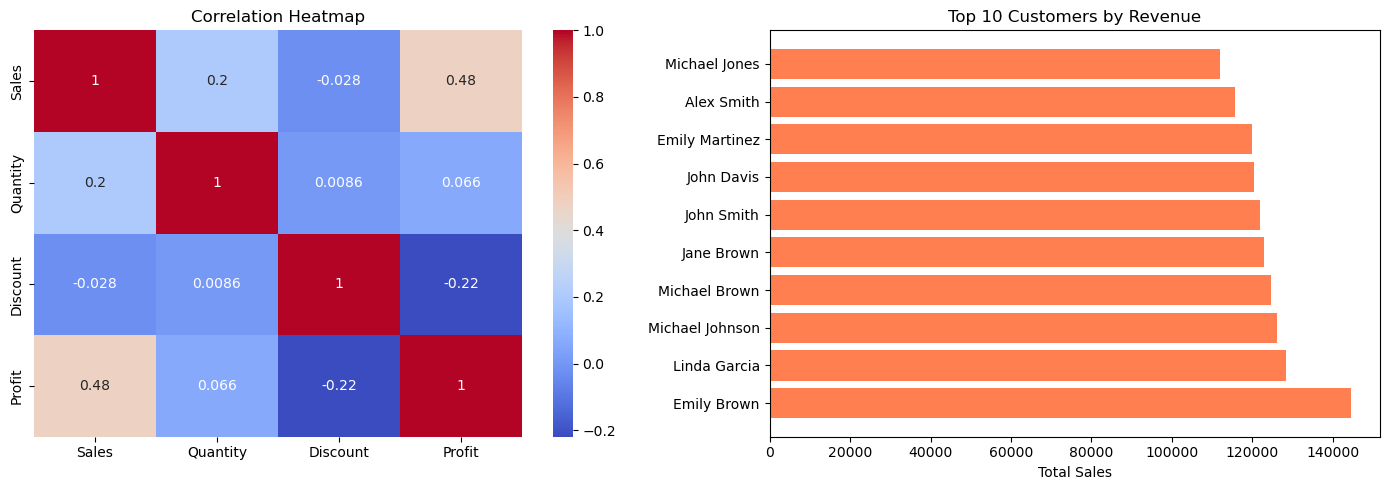

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Correlation Heatmap
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation Heatmap')

# 2. Top 10 Customers by Revenue (RFM - Monetary)
top_customers = df.groupby('FullName')['Sales'].sum().sort_values(ascending=False).head(10)
axes[1].barh(top_customers.index, top_customers.values, color='coral')
axes[1].set_title('Top 10 Customers by Revenue')
axes[1].set_xlabel('Total Sales')

plt.tight_layout()
plt.show()